In [7]:
!pip install scratch

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for scratch: filename=scratch-1.0.0-py2.py3-none-any.whl size=4989 sha256=18c6a182096e1f0a1025ac8356e9c408265c98e8f9a6d4619d9052a78797ed13
  Stored in directory: c:\users\nazar\appdata\local\pip\cache\wheels\0a\a8\01\b43d18d044d2df0ce3be5895f40e8d7cf6821386e08de73179
Successfully built scratch


In [184]:
from typing import Tuple, List
import matplotlib.pyplot as plt
import numpy as np
import random
import math

In [79]:
def normal_cdf(x: float, mu: float = 0, sigma: float = 1) -> float:
    return (1 + math.erf((x - mu) / (sigma * math.sqrt(2)))) / 2

In [80]:
normal_probaЬility_below = normal_cdf

In [81]:
def normal_probability_above(lo: float, mu: float = 0, sigma: float = 1) -> float:
    return 1 - normal_cdf(lo, mu, sigma)

In [82]:
def normal_probability_between(lo: float, hi: float, mu: float = 0, sigma: float = 1) -> float:
    return normal_cdf(lo, mu, sigma) - normal_cdf(lo, mu, sigma)

In [83]:
def normal_probability_outside(lo: float, hi: float, mu: float = 0, sigma: float = 1) -> float:
    return 1 - normal_probabilty_between(lo, hi, mu, sigma)

In [84]:
def inverse_normal_cdf(p: float, mu: float = 0, sigma: float = 1, tolerance: float = 0.00001) -> float:
    if mu != 0 or sigma != 1:
        return mu + sigma * inverse_normal_cdf(p, tolerance = tolerance)
    low_z = -10.0
    hi_z = 10.0
    while (hi_z - low_z) > tolerance:
        mid_z = (low_z + hi_z) / 2
        mid_p = normal_cdf(mid_z)
        if mid_p < p:
            low_z = mid_z
        else:
            hi_z = mid_z
    return mid_z

In [85]:
def normal_upper_bound(probability: float, mu: float = 0, sigma: float = 1) -> float:
    return inverse_normal_cdf(probability, mu, sigma)

In [86]:
def normal_lower_bound(probability: float, mu: float = 0, sigma: float = 1) -> float:
    return inverse_normal_cdf(1 - probability, mu, sigma)

In [126]:
def normal_two_sided_bounds(probability: float, mu: float = 0, sigma: float = 1) -> Tuple[float, float]:
    tail_probability = (1 - probability) / 2
    upper_bound = normal_lower_bound(tail_probability, mu, sigma)
    lower_bound = normal_upper_bound(tail_probability, mu, sigma)
    return lower_bound, upper_bound

In [88]:
def normal_approximation_to_binomial(n: int, p: float) -> Tuple[float, float]:
    mu = p * n
    sigma = math.sqrt(p * (1 - p) * n)
    return mu, sigma

In [89]:
mu_0, sigma_0 = normal_approximation_to_binomial(1000, 0.5)

In [90]:
mu_1, sigma_1 = normal_approximation_to_binomial(1000, 0.55)

In [91]:
lower_bound, upper_bound =  normal_two_sized_bounds(0.95, mu_0, sigma_0)

In [92]:
lo, hi = normal_two_sized_bounds(0.95, mu_0, sigma_0)

In [93]:
error_type_2_probability = normal_probability_between(lo, hi, mu_1, sigma_1)

In [94]:
power = 1 - error_type_2_probability

In [68]:
error_type_2_probaЬility = normal_probaЬility_below(hi, mu_1, sigma_1) 

In [69]:
power = 1 - error_type_2_probability 

In [102]:
def two_sided_p_value(x: float, mu: float = 0, sigma: float = 1) -> float:
    if x >= mu:
        return 2 * normal_probability_above(x, mu, sigma)
    else:
        return 2 * normal_probability_below(x, mu, sigma)

In [103]:
print(f"p-value: {two_sided_p_value(529.5, mu_0, sigma_0):.3f}")

p-value: 0.062


In [104]:
p_value = two_sided_p_value(529.5, mu_0, sigma_0)

In [180]:
extreme_value_count = 0

In [181]:
random.seed(0)

In [182]:
for _ in range(1000):
    num_heads = sum(1 if random.random() < 0.5 else 0 for _ in range(1000))
    if num_heads >= 530 or num_heads <= 470:
        extreme_value_count += 1

In [183]:
assert 59 < extreme_value_count < 65, f"{extreme_value_count}"

In [111]:
print(f"p-value: {two_sided_p_value(531.5, mu_0, sigma_0):.3f}")

p-value: 0.046


In [114]:
upper_p_value = normal_probability_above
lower_p_value = normal_probaЬility_below

In [119]:
print(f"upper p-value: {upper_p_value(524.5, mu_0, sigma_0):.4f}")

upper p-value: 0.0606


In [120]:
print(f"upper p-value: {upper_p_value(526.5, mu_0, sigma_0):.4f}")

upper p-value: 0.0469


In [123]:
p_hat = 525 / 1000
mu = p_hat
sigma = math.sqrt(p_hat * (1 - p_hat) / 1000)

In [124]:
print(f"sigma: {sigma:.4f}")

sigma: 0.0158


In [135]:
print(f"normal two sided bounds: {normal_two_sided_bounds(0.95, mu, sigma)}")

normal two sided bounds: (0.5091095927295919, 0.5708904072704082)


In [136]:
p_hat = 540 / 1000
mu = p_hat
sigma = math.sqrt(p_hat * (1 - p_hat) / 1000)
print(f"normal two sided bounds: {normal_two_sided_bounds(0.95, mu, sigma)}")

normal two sided bounds: (0.5091095927295919, 0.5708904072704082)


In [139]:
def run_experiment() -> List[bool]:
    return [random.random() < 0.5 for _ in range(1000)]

In [151]:
def reject_fairness(experiment: List[bool]) -> bool:
    num_heads = len([flip for flip in experiment if flip])
    return num_heads < 469 or num_heads > 531

In [152]:
random.seed(0)

In [153]:
experiments = [run_experiment() for _ in range(1000)]

In [155]:
num_rejections = len([experiment for experiment in experiments if reject_fairness(experiment)])

In [156]:
assert num_rejections == 46

In [161]:
def estemated_parameters(N: int, n: int) -> Tuple[float, float]:
    p = n / N
    sigma = math.sqrt(p * (1 - p) / N)
    return p, sigma

In [165]:
def a_b_test_statistics(N_A: int, n_A: int, N_B: int, n_B: int) -> float:
    p_A, sigma_A, = estemated_parameters(N_A, n_A)
    p_B, sigma_B = estemated_parameters(N_B, n_B)
    return (p_B - p_A) / math.sqrt(sigma_A ** 2 + sigma_B ** 2)

In [170]:
z = a_b_test_statistics(1000, 200, 1000, 180)
two_sided_p_value_ = two_sided_p_value(z)

In [173]:
print(f"z: {z:.4f}")
print(f"two_sided_p_value_: {two_sided_p_value_:.4f}")

z: -1.1403
two_sided_p_value_: 0.2541


In [174]:
z = a_b_test_statistics(1000, 200, 1000, 150)
two_sided_p_value_ = two_sided_p_value(z)

In [175]:
print(f"z: {z:.4f}")
print(f"two_sided_p_value_: {two_sided_p_value_:.4f}")

z: -2.9488
two_sided_p_value_: 0.0032


In [198]:
def visualize_ab_test(z_score, p_value, test_name):
    x = np.linspace(-4, 4, 1000)
    y = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x ** 2)
    plt.figure(figsize = (10, 6))
    plt.plot(x, y, label = "Standard Normal Distribution", color = '#2ecc71', linewidth = 2)
    plt.fill_between(x, y, alpha = 0.1, color = '#2ecc71')
    plt.axvline(z_score, color = '#e74c3c', linestyle = '--', linewidth = 2, label=f'Z-score = {z_score:.4f}\np-value = {p_value:.4f}')
    if z_score < 0:
        fill_x_left = x[x <= z_score]
        plt.fill_between(fill_x_left, y[x <= z_score], color = '#e74c3c', alpha = 0.5)
        fill_x_right = x[x >= -z_score]
        plt.fill_between(fill_x_right, y[x >= -z_score], color = '#e74c3c', alpha = 0.5)
    else:
        fill_x_right = x[x >= z_score]
        plt.fill_between(fill_x_right, y[x >= z_score], color='#e74c3c', alpha = 0.5)
        fill_x_left = x[x <= -z_score]
        plt.fill_between(fill_x_left, y[x <= -z_score], color='#e74c3c', alpha = 0.5)
    plt.title(f'A/B Testing Results: {test_name}', fontsize = 16, pad = 15)
    plt.xlabel('Z-score', fontsize = 12)
    plt.ylabel('Probability Density', fontsize = 12)
    plt.axvline(0, color = 'black', linewidth = 2, alpha = 0.3)
    plt.legend(loc = 'upper right', fontsize = 11, frameon = True, shadow = True)
    plt.grid(True, linestyle = ':', alpha = 0.6)

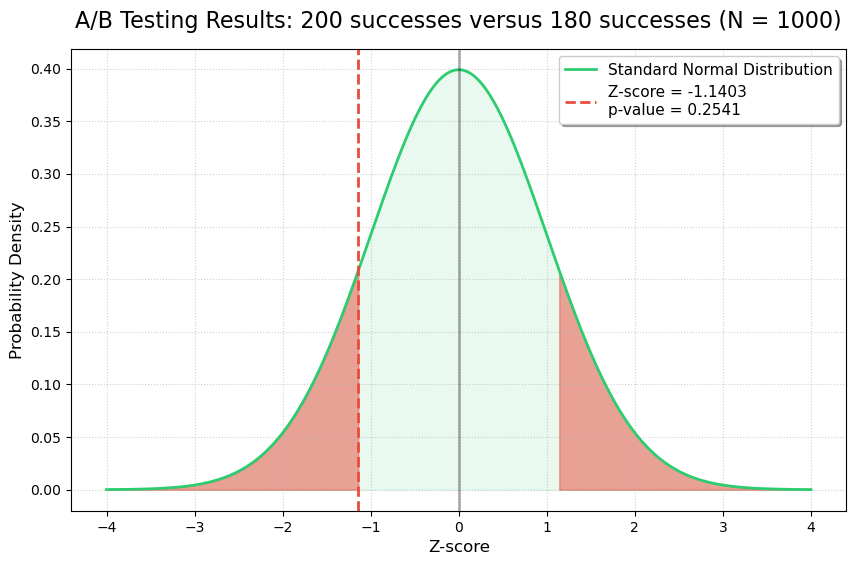

In [199]:
z_1 = a_b_test_statistics(1000, 200, 1000, 180)
p_val_1 = two_sided_p_value(z_1)
visualize_ab_test(z_1, p_val_1, "200 successes versus 180 successes (N = 1000)")

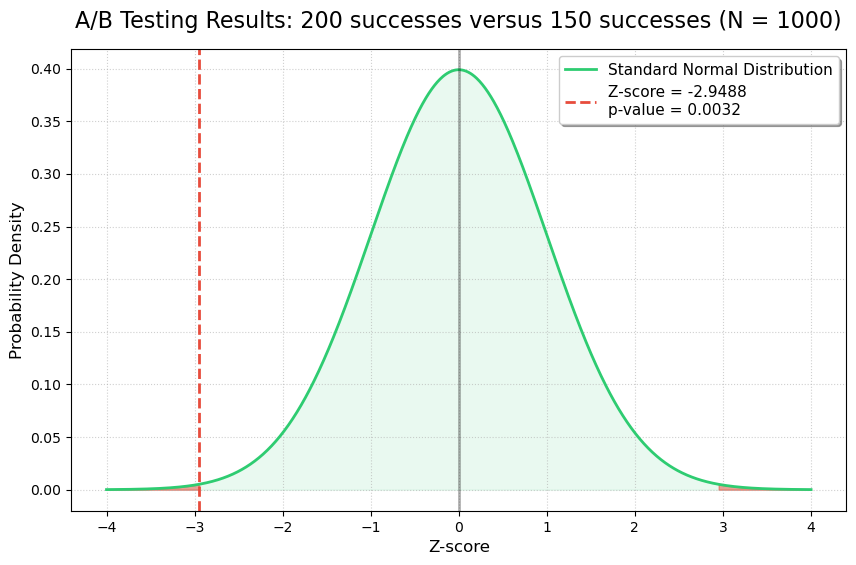

In [200]:
z_2 = a_b_test_statistics(1000, 200, 1000, 150)
p_val_2 = two_sided_p_value(z_2)
visualize_ab_test(z_2, p_val_2, "200 successes versus 150 successes (N = 1000)")